# Lab 6.18

This is the initial introduction of building ANNs using Keras and Tensorflow.

In [1]:
import tensorflow as tf

I0000 00:00:1778495108.382390    6565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778495108.420056    6565 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778495109.385500    6565 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [4]:
X_train.shape

(55000, 28, 28)

In [5]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test_full / 255.

Build the class names to distinguish

In [6]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [7]:
class_names[y_train[0]]

'Ankle boot'

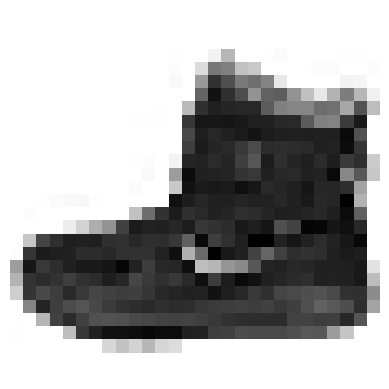

In [8]:
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='binary')
plt.axis('off')
plt.show()

## Creating the model using a sequential API

We'll now create the model using nuerons

In [9]:
tf.random.set_seed(13)   # unlucky for some
model = tf.keras.Sequential([
    tf.keras.Input(shape=[28, 28]), # Add an Input layer as the first layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(300, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

E0000 00:00:1778495121.104390    6565 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778495121.104629    6596 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778495121.117786    6565 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [12]:
# Fit the model
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid), verbose=0)

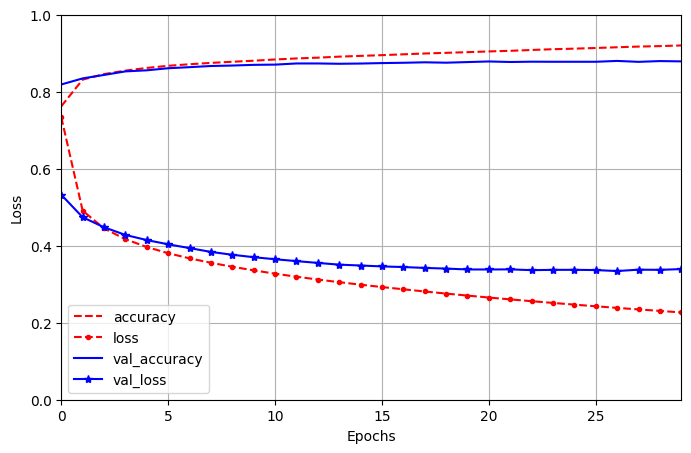

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(
    figsize=(8, 5),
    xlim=[0,29], ylim =[0,1], xlabel='Epochs', ylabel='Loss', grid=True,
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

# MNIST: Perceptron vs Neuron

So now we'll make perceptron vs neuron model of the MNIST dataet

In [14]:
# import data
mnist = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [15]:
# Split data
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist

X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [16]:
X_train.shape

(55000, 28, 28)

In [17]:
# Standardize

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test_full / 255.

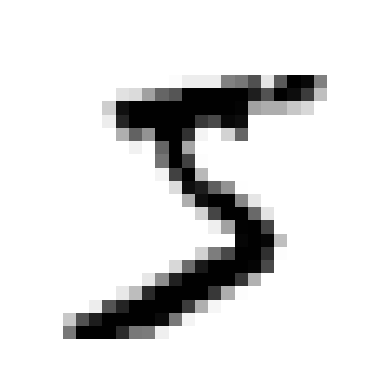

5


In [18]:
# Check first train line
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='binary')
plt.axis('off')
plt.show()

print(y_train[0])

## Config models

In [19]:
tf.random.set_seed(13)   # unlucky for some

neuron_model = tf.keras.Sequential([
    tf.keras.Input(shape=[28, 28]), # Add an Input layer as the first layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


perceptron_model = tf.keras.Sequential([
    tf.keras.Input(shape=[28, 28]), # Add an Input layer as the first layer
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='hard_sigmoid'),
    tf.keras.layers.Dense(128, activation='hard_sigmoid'),
    tf.keras.layers.Dense(64, activation='hard_sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [20]:
neuron_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
perceptron_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
neuron_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

perceptron_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit the neuron_model
print("Fitting neuron_model...")
neuron_history = neuron_model.fit(X_train, y_train, epochs=50, verbose=2, validation_data=(X_valid, y_valid))

# Fit the perceptron_model
print("Fitting perceptron_model...")
perceptron_history = perceptron_model.fit(X_train, y_train, epochs=50, verbose=2, validation_data=(X_valid, y_valid))

# Create dataframes from histories
neuron_df = pd.DataFrame(neuron_history.history)
perceptron_df = pd.DataFrame(perceptron_history.history)

# Rename columns to distinguish between models
neuron_df = neuron_df.add_prefix('neuron_')
perceptron_df = perceptron_df.add_prefix('perceptron_')

# Combine dataframes for plotting
combined_df = pd.concat([neuron_df, perceptron_df], axis=1)

Fitting neuron_model...
Epoch 1/50
1719/1719 - 3s - 2ms/step - accuracy: 0.8324 - loss: 0.6261 - val_accuracy: 0.9314 - val_loss: 0.2418
Epoch 2/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9219 - loss: 0.2693 - val_accuracy: 0.9470 - val_loss: 0.1843
Epoch 3/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9390 - loss: 0.2122 - val_accuracy: 0.9572 - val_loss: 0.1542
Epoch 4/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9492 - loss: 0.1759 - val_accuracy: 0.9622 - val_loss: 0.1344
Epoch 5/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9564 - loss: 0.1500 - val_accuracy: 0.9662 - val_loss: 0.1208
Epoch 6/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9625 - loss: 0.1303 - val_accuracy: 0.9688 - val_loss: 0.1109
Epoch 7/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9672 - loss: 0.1145 - val_accuracy: 0.9712 - val_loss: 0.1034
Epoch 8/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9711 - loss: 0.1013 - val_accuracy: 0.9730 - val_loss: 0.0973
Epoch 9/50
1719/1719 - 2s - 1ms/step - accuracy: 0.9749 - loss: 0.0900 -

### Note

While the neuron network does have much better results, past 15 epochs the validation loss function actually starts to increase against the decreasing training loss.

This indicates overfitting!!!

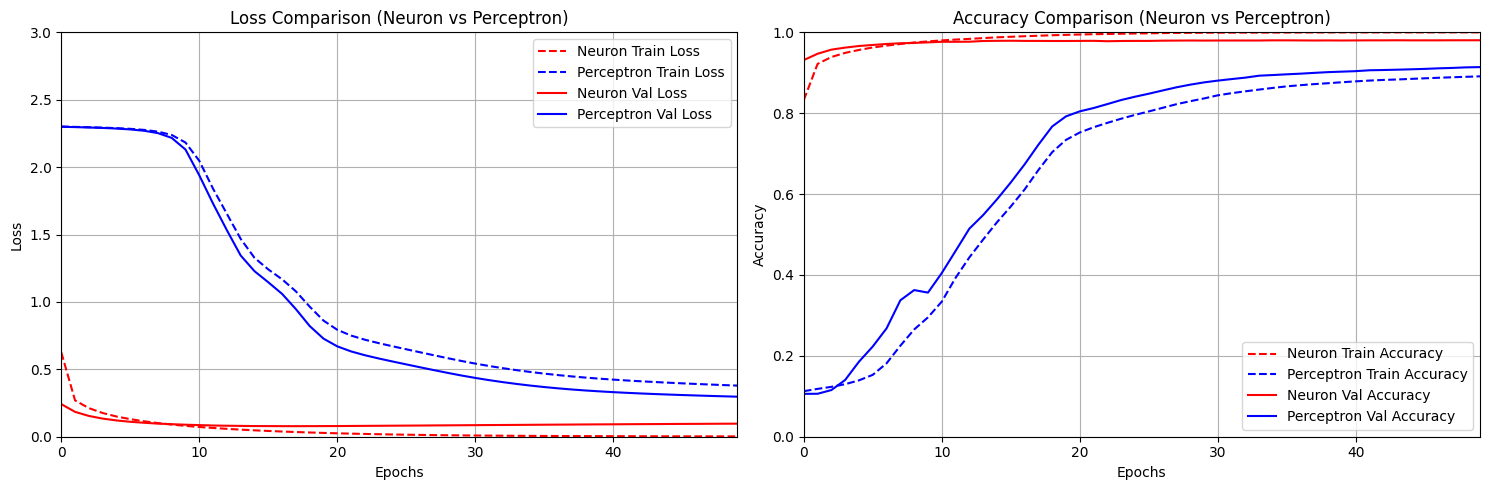

In [24]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
combined_df[['neuron_loss', 'perceptron_loss', 'neuron_val_loss', 'perceptron_val_loss']].plot(ax=ax1,
    xlim=[0,49], ylim =[0,3], xlabel='Epochs', ylabel='Loss', grid=True,
    style=["r--", "b--", "r-", "b-"]
)
ax1.set_title('Loss Comparison (Neuron vs Perceptron)')
ax1.legend(['Neuron Train Loss', 'Perceptron Train Loss', 'Neuron Val Loss', 'Perceptron Val Loss'])

# Plot accuracy
combined_df[['neuron_accuracy', 'perceptron_accuracy', 'neuron_val_accuracy', 'perceptron_val_accuracy']].plot(ax=ax2,
    xlim=[0,49], ylim =[0,1], xlabel='Epochs', ylabel='Accuracy', grid=True,
    style=["r--", "b--", "r-", "b-"]
)
ax2.set_title('Accuracy Comparison (Neuron vs Perceptron)')
ax2.legend(['Neuron Train Accuracy', 'Perceptron Train Accuracy', 'Neuron Val Accuracy', 'Perceptron Val Accuracy'])

plt.tight_layout()
plt.show()

In [25]:
print("\nEvaluating neuron_model on test data...")
neuron_test_loss, neuron_test_accuracy = neuron_model.evaluate(X_test, y_test_full, verbose=2)
print(f"Neuron Model - Test Loss: {neuron_test_loss:.4f}, Test Accuracy: {neuron_test_accuracy:.4f}")

print("\nEvaluating perceptron_model on test data...")
perceptron_test_loss, perceptron_test_accuracy = perceptron_model.evaluate(X_test, y_test_full, verbose=2)
print(f"Perceptron Model - Test Loss: {perceptron_test_loss:.4f}, Test Accuracy: {perceptron_test_accuracy:.4f}")


Evaluating neuron_model on test data...
313/313 - 0s - 998us/step - accuracy: 0.9785 - loss: 0.0839
Neuron Model - Test Loss: 0.0839, Test Accuracy: 0.9785

Evaluating perceptron_model on test data...
313/313 - 0s - 969us/step - accuracy: 0.8964 - loss: 0.3642
Perceptron Model - Test Loss: 0.3642, Test Accuracy: 0.8964


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step


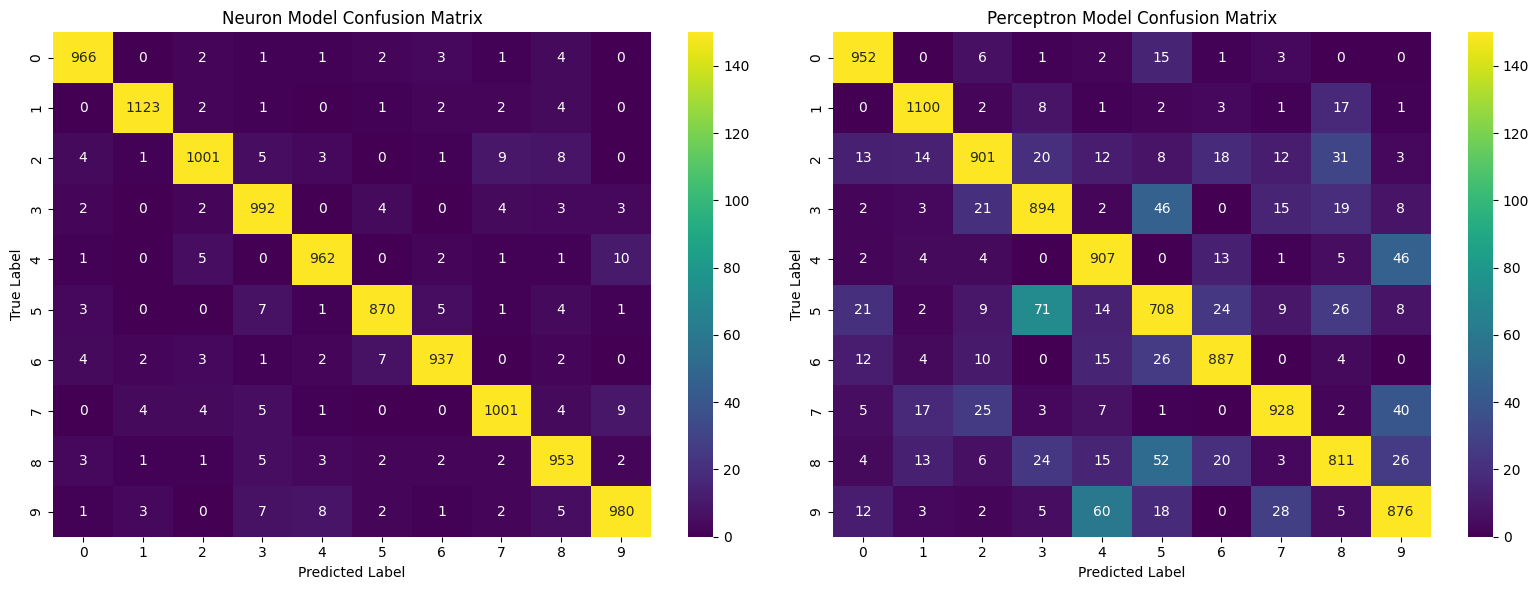

In [26]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define class names for MNIST (digits 0-9)
class_names = [str(i) for i in range(10)]

# Predict classes for neuron_model
neuron_y_pred_probs = neuron_model.predict(X_test)
neuron_y_pred = np.argmax(neuron_y_pred_probs, axis=1)

# Predict classes for perceptron_model
perceptron_y_pred_probs = perceptron_model.predict(X_test)
perceptron_y_pred = np.argmax(perceptron_y_pred_probs, axis=1)

# Generate confusion matrices
neuron_cm = confusion_matrix(y_test_full, neuron_y_pred)
perceptron_cm = confusion_matrix(y_test_full, perceptron_y_pred)

# Plotting confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Neuron Model Confusion Matrix
sns.heatmap(neuron_cm, annot=True, fmt='d', cmap='viridis', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, vmax=150)
axes[0].set_title('Neuron Model Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Perceptron Model Confusion Matrix
sns.heatmap(perceptron_cm, annot=True, fmt='d', cmap='viridis', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, vmax=150)
axes[1].set_title('Perceptron Model Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()